# Scikit-Learn Integration: Pipelines & Grid Search

One of the main advantages of **randomized-svd** v0.3.0+ is its full compatibility with the Scikit-Learn ecosystem.

The `RandomizedSVD` class follows the standard **Estimator API** (`fit`, `transform`, `get_params`), meaning it can be used as a drop-in replacement for `TruncatedSVD` or `PCA`.

In this notebook, we will demonstrate:

1. **Drop-in Replacement:** How to switch from standard PCA/SVD to RandomizedSVD.
2. **Pipelines:** Chaining dimensionality reduction with a classifier.
3. **Hyperparameter Tuning:** Using `GridSearchCV` to automatically find the best rank .

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import classification_report

# Import our library
from randomized_svd import RandomizedSVD

# Load Data (Handwritten Digits)
# X shape: (1797 samples, 64 features) -> 8x8 pixel images
data = load_digits()
X, y = data.data, data.target

print(f"Dataset Shape: {X.shape}")
print(f"Target Classes: {np.unique(y)}")


Dataset Shape: (1797, 64)
Target Classes: [0 1 2 3 4 5 6 7 8 9]



## 1. Visual Comparison: Deterministic vs Randomized

Let's project the 64-dimensional data into 2D space to visualize the clusters. We will compare the standard Scikit-Learn `TruncatedSVD` (ARPACK solver) against our `RandomizedSVD`.

They should produce visually similar clusters, proving that the approximation is accurate.

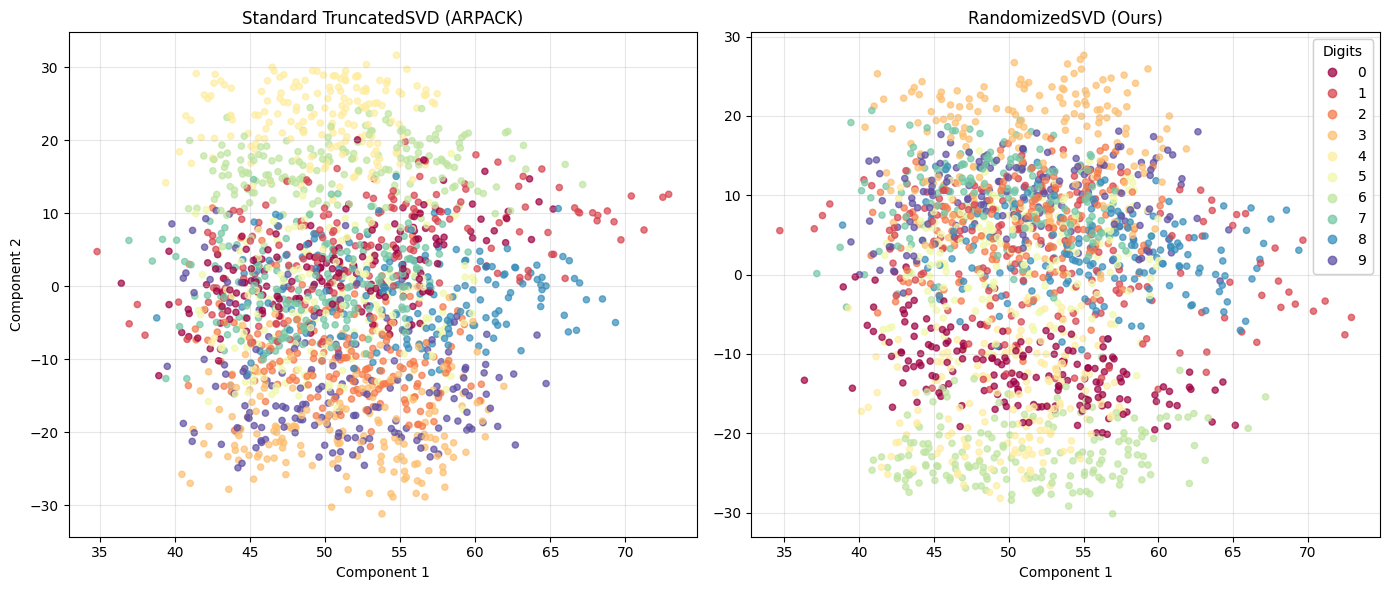

Observation: The cluster structure is preserved identically.


In [2]:
# 1. Standard Scikit-Learn SVD
svd_std = TruncatedSVD(n_components=2, random_state=42)
X_std = svd_std.fit_transform(X)

# 2. Our Randomized SVD
svd_rand = RandomizedSVD(n_components=2, random_state=42)
X_rand = svd_rand.fit_transform(X)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Standard
scatter = axes[0].scatter(X_std[:, 0], X_std[:, 1], c=y, cmap='Spectral', alpha=0.7, s=20)
axes[0].set_title('Standard TruncatedSVD (ARPACK)')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')
axes[0].grid(True, alpha=0.3)

# Plot Randomized
axes[1].scatter(X_rand[:, 0], X_rand[:, 1], c=y, cmap='Spectral', alpha=0.7, s=20)
axes[1].set_title('RandomizedSVD (Ours)')
axes[1].set_xlabel('Component 1')
axes[1].grid(True, alpha=0.3)

# Add legend
legend1 = axes[1].legend(*scatter.legend_elements(), title="Digits", loc="upper right")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

print("Observation: The cluster structure is preserved identically.")
# Note: The sign of components might be flipped (SVD ambiguity), but the geometry is the same.

## 2. Building a Machine Learning Pipeline

A common workflow in Data Science is:
`Normalization`  `Dimensionality Reduction`  `Classification`.

We will build a **Pipeline** to classify the digits. We reduce the features from 64 to 30 using `RandomizedSVD` to speed up the Support Vector Machine (SVM) and remove noise.

In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),                 # Step 1: Scale data
    ('rsvd',   RandomizedSVD(n_components=30)),   # Step 2: Reduce dims (Our Library)
    ('svm',    SVC(kernel='rbf', class_weight='balanced')) # Step 3: Classify
])

# Train the whole pipeline
print("Training Pipeline...")
pipe.fit(X_train, y_train)

# Evaluate
accuracy = pipe.score(X_test, y_test)
print(f"Test Set Accuracy: {accuracy:.2%}")


Training Pipeline...
Test Set Accuracy: 97.59%


## 3. Automatic Hyperparameter Tuning (Grid Search)

Since `RandomizedSVD` exposes `get_params()` and `set_params()`, we can tune it using **GridSearchCV**.

We want to find the optimal trade-off:

* **Too few components:** Information loss (Underfitting).
* **Too many components:** Noise inclusion (Overfitting) and slower training.

We will verify which Rank () gives the best classification accuracy.

In [4]:
# Define parameter grid
# Note: 'rsvd__n_components' maps to the 'n_components' parameter of the 'rsvd' step
param_grid = {
    'rsvd__n_components': [10, 20, 30, 40, 50],
    'rsvd__n_oversamples': [5, 10]
}

# Setup Grid Search
grid = GridSearchCV(
    pipe, 
    param_grid, 
    cv=5,            # 5-Fold Cross Validation
    n_jobs=-1,       # Use all CPU cores
    verbose=1
)

# Run Grid Search
print("Starting Grid Search to find optimal Rank...")
grid.fit(X_train, y_train)

# Results
print("\n--- Best Parameters Found ---")
print(grid.best_params_)
print(f"Best CV Score: {grid.best_score_:.2%}")

# Validate on Test Set with best model
best_model = grid.best_estimator_
test_acc = best_model.score(X_test, y_test)
print(f"\nFinal Test Accuracy (Best Model): {test_acc:.2%}")


Starting Grid Search to find optimal Rank...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- Best Parameters Found ---
{'rsvd__n_components': 50, 'rsvd__n_oversamples': 5}
Best CV Score: 97.85%

Final Test Accuracy (Best Model): 98.15%


## 4. Inverse Transform (Reconstruction)

Finally, let's verify the `inverse_transform` capability. We will compress a digit image and then reconstruct it to see how much detail is preserved.

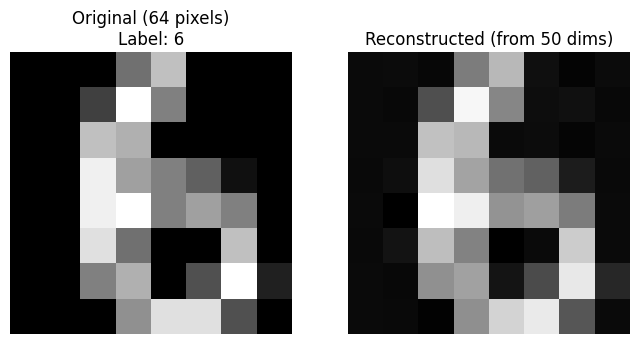

In [5]:
# Pick a random digit from test set
idx = 0
original_img = X_test[idx].reshape(8, 8)

# Transform (Compress) using the best model found
# Note: We need to access the 'rsvd' step from the pipeline
rsvd_step = best_model.named_steps['rsvd']
scaler_step = best_model.named_steps['scaler']

# Manual step-by-step to show reconstruction
X_scaled = scaler_step.transform(X_test[idx].reshape(1, -1))
X_reduced = rsvd_step.transform(X_scaled)

# Inverse Transform (Reconstruct)
X_reconstructed_scaled = rsvd_step.inverse_transform(X_reduced)
X_reconstructed = scaler_step.inverse_transform(X_reconstructed_scaled) # Un-scale

reconstructed_img = X_reconstructed.reshape(8, 8)

# Plot
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title(f"Original (64 pixels)\nLabel: {y_test[idx]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img, cmap='gray')
k = grid.best_params_['rsvd__n_components']
plt.title(f"Reconstructed (from {k} dims)")
plt.axis('off')

plt.show()
